<a href="https://colab.research.google.com/github/Karunakar2701/Basic-deep-learning-projects-for-Learning/blob/main/Handwritten_Digit_Recognition_using_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
import torchvision

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [21]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, Subset
from torchvision.transforms import ToTensor
from torchvision import datasets

In [22]:
training_data_full = datasets.MNIST(
    root= "data",
    train= True,
    download= True,
    transform=ToTensor()
)

testing_data_full = datasets.MNIST(
    root= "data",
    train= False,
    download = True,
    transform= ToTensor()
)

In [23]:
training_data = Subset(training_data_full, range(10000))
testing_data = Subset(testing_data_full, range(1000))

In [24]:
len(training_data), len(testing_data)

(10000, 1000)

In [25]:
img, label = training_data[4]
print(label)
img.shape

9


torch.Size([1, 28, 28])

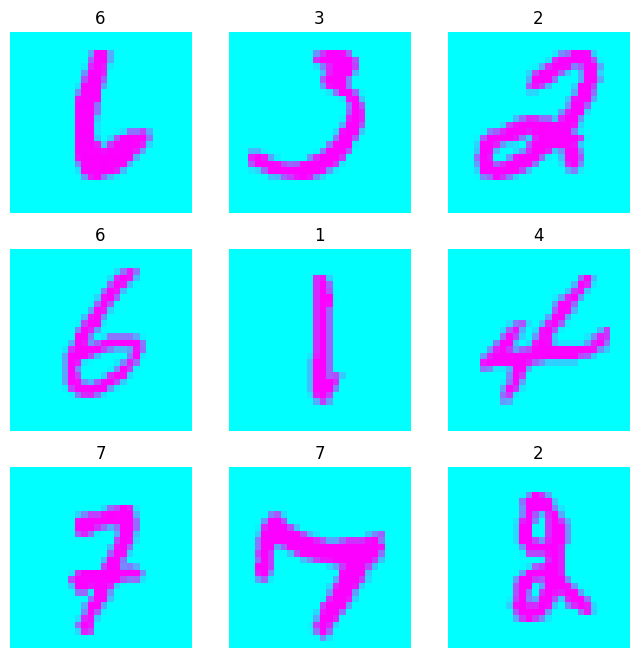

In [26]:
labels = [0,1,2,3,4,5,6,7,8,9]
figure = plt.figure(figsize=(8,8))
cols, rows =3, 3
for i in range(1, cols * rows +1):
  sample_indx = torch.randint(len(training_data), size=(1,)).item() #size=(1,) defines tuple and output 1D tensor
  img, label = training_data[sample_indx]
  figure.add_subplot(rows, cols, i)
  plt.title(labels[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="cool")
plt.show()

In [27]:
from torch.utils.data import DataLoader
BATCHSIZE =32
train_dataloader = DataLoader(
     dataset = training_data,
     batch_size= BATCHSIZE,
     shuffle= True
)

test_dataloader = DataLoader(
    dataset= testing_data,
    batch_size= BATCHSIZE
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c9b9c3c9b80>,
 <torch.utils.data.dataloader.DataLoader at 0x7c9b9e263170>)

 Feature Batch size: torch.Size([32, 1, 28, 28])
 Labels Batch size: torch.Size([32])


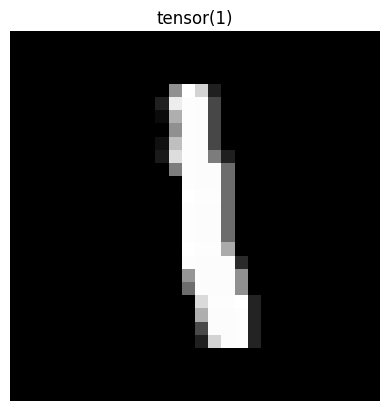

In [28]:

train_features, train_labels = next(iter(train_dataloader))
print(f" Feature Batch size: {train_features.size()}" )
print(f" Labels Batch size: {train_labels.size()}")

img = train_features[0]
label = train_labels[0]
plt.imshow(img.squeeze(), cmap="grey")
plt.title(label)
plt.axis(False)
plt.show()

In [29]:
train_features.shape

torch.Size([32, 1, 28, 28])

In [30]:
len(labels)

10

In [31]:
# from torch import nn
# class MnistModel0(nn.Module):
#   def __init__(self, input_size ,hidden_units, output_size):
#     super().__init__()
#     self.conv1 = nn.Sequential(
#         nn.Conv2d(in_channels=input_size, out_channels=hidden_units,kernel_size=2, stride=2, padding =1),
#         nn.ReLU(),
#         nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,kernel_size=2,stride=1,padding=1),
#         nn.Relu())

#   def forward(self, x):
#     return self.conv1(x)

In [32]:
# model0 = MnistModel0(,hidden_units=5, output_size=len(labels))
# model0

In [33]:
from torch import nn
class MN0(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512,10))
  def forward(self, x):
    x= self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

In [34]:
model = MN0()
model = model.to(device)
print(model)

MN0(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [35]:
X = torch.rand(1,28,28).to(device)
logits = model(X)
prob = nn.Softmax(dim=1)(logits)
pred = prob.argmax()
print(pred)


tensor(5, device='cuda:0')


In [36]:
len(train_dataloader)

313

In [37]:
313 * 32

10016

In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [39]:
import torch
def train(model: torch.nn.Module,
          dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer : torch.optim.Optimizer,
          device: torch.device ):
  model.train()
  total_loss, total_correct = 0, 0

  total_samples =0
  for Batch,(X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      logits = model(X)
      loss = loss_fn(logits,y)
      pred = logits.argmax(dim=1)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_loss +=loss.item()
      total_correct +=torch.eq(pred, y).sum().item()
      total_samples += len(y)

  avg_loss = total_loss / len(dataloader)
  avg_acc = total_correct / total_samples
  return avg_loss, avg_acc

In [40]:
train(model, train_dataloader,loss_fn, optimizer, device)

(0.49743449760559266, 0.8496)

In [41]:
epochs = 10
total_loss = 0
total_acc = 0
for epoch in range(epochs):
  loss, acc = train(model, train_dataloader,loss_fn, optimizer, device)
  print(f"Epch: {epoch +1} | Loss: {loss:.4f} | acc: {acc:.3f}")



Epch: 1 | Loss: 0.2762 | acc: 0.923
Epch: 2 | Loss: 0.2496 | acc: 0.934
Epch: 3 | Loss: 0.1954 | acc: 0.947
Epch: 4 | Loss: 0.1988 | acc: 0.950
Epch: 5 | Loss: 0.1600 | acc: 0.958
Epch: 6 | Loss: 0.1386 | acc: 0.965
Epch: 7 | Loss: 0.1502 | acc: 0.965
Epch: 8 | Loss: 0.1431 | acc: 0.964
Epch: 9 | Loss: 0.1002 | acc: 0.973
Epch: 10 | Loss: 0.1144 | acc: 0.973


In [42]:
def test(model: torch.nn.Module,
         dataloader : torch.utils.data.DataLoader,
         loss_fn: torch.nn.Module,
         device: torch.device):
  model.eval()
  count = 0
  acc = 0
  avg_loss = 0

  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
       X, y = X.to(device), y.to(device)
       logits = model(X)
       loss = loss_fn(logits, y)
       pred = logits.argmax(dim=1)
       avg_loss += loss.item()
       acc += torch.eq(pred, y).sum().item()
       count +=len(y)

       if batch % 10 ==0:
         print(f"Batch: {batch} | test loss:{avg_loss/(batch+1):.4f} | acc: {acc/count:.4f}")
  return avg_loss/len(dataloader), acc/count


In [43]:
test(model,test_dataloader,loss_fn, device)

Batch: 0 | test loss:0.2794 | acc: 0.9688
Batch: 10 | test loss:0.2933 | acc: 0.9290
Batch: 20 | test loss:0.3409 | acc: 0.9226
Batch: 30 | test loss:0.3482 | acc: 0.9264


(0.3402977109653875, 0.927)

In [44]:
# import random
# k=6
# test_data = random.sample(range(len(testing_data_full)), k)




In [45]:
classes = training_data_full.classes

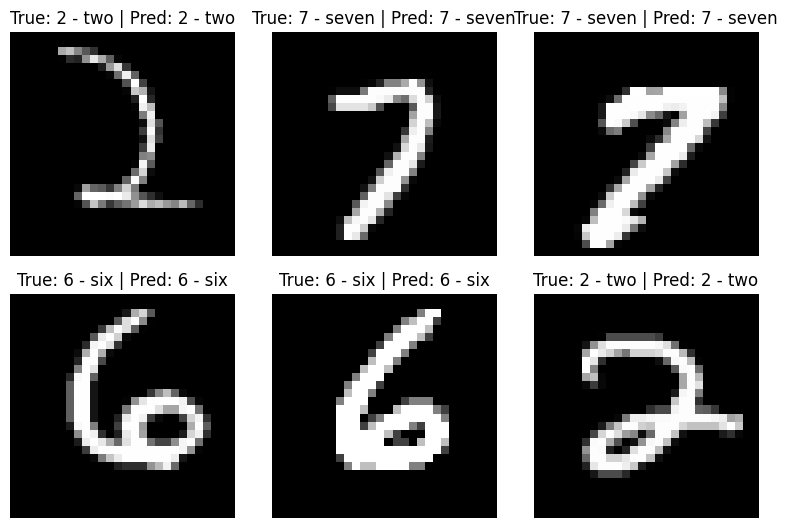

In [46]:
import torch
import matplotlib.pyplot as plt

k = 6
indices = torch.randperm(len(testing_data_full))[:k]
samples = [testing_data_full[i] for i in indices]

model.eval()
device = next(model.parameters()).device

plt.figure(figsize=(8, 8))

with torch.inference_mode():
    for i, (img, label) in enumerate(samples):

        img_input = img.unsqueeze(0).to(device)


        logits = model(img_input)
        pred_idx = logits.argmax(dim=1).item()

        pred = classes[pred_idx]
        true = classes[label]

        plt.subplot(3, 3, i + 1)
        plt.imshow(img.squeeze(), cmap="gray")

        plt.title(f"True: {true} | Pred: {pred}")
        plt.axis(False)

plt.tight_layout()
plt.show()

In [47]:
print(type(testing_data_full[i]))

<class 'tuple'>


In [48]:
full_test_dataloader = DataLoader(dataset=testing_data_full,
                                  batch_size =32,
                                  shuffle=True)
print(full_test_dataloader)
len(full_test_dataloader)

313

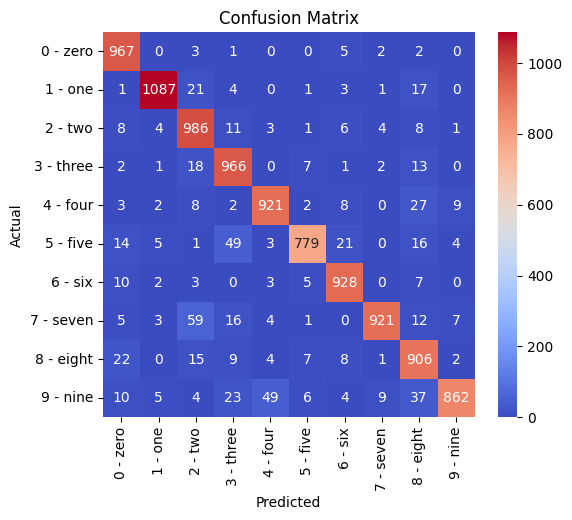

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


all_labels = []
all_preds = []
model.eval()
with torch.inference_mode():
  for batch, (X, y) in enumerate(full_test_dataloader):
    X, y = X.to(device), y.to(device)
    pred_logit = model(X)
    preds = pred_logit.argmax(dim=1)
    """IMP: moving to cpu and convert to numpy because numpy works only on cpu
    not gpu and confusion matrix also """
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt = "d",
            cmap="coolwarm",
            xticklabels = classes,
            yticklabels= classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [50]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average = 'weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9323
Precision: 0.9348
Recall : 0.9323
F1 Score: 0.9323


In [51]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       980
           1       0.98      0.96      0.97      1135
           2       0.88      0.96      0.92      1032
           3       0.89      0.96      0.92      1010
           4       0.93      0.94      0.94       982
           5       0.96      0.87      0.92       892
           6       0.94      0.97      0.96       958
           7       0.98      0.90      0.94      1028
           8       0.87      0.93      0.90       974
           9       0.97      0.85      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

